In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
drive_root = '/content/drive/MyDrive'
print("Files and folders in your Google Drive root:")
print(os.listdir(drive_root))

Files and folders in your Google Drive root:
['Classroom', 'Calculus Assignment.pdf', 'TapScanner02-04-2024-1915 (3).pdf', 'TapScanner02-04-2024-1915 (2).pdf', 'TapScanner02-04-2024-1915 (1).pdf', 'TapScanner02-04-2024-1915.pdf', 'TapScanner02-04-2024-1946(1).pdf', 'TapScanner02-04-2024-2044 (1).pdf', 'TapScanner02-04-2024-2044.pdf', 'TapScanner02-04-2024-2047 (1).pdf', 'TapScanner02-04-2024-2047.pdf', 'TapScanner02-18-2024-2315 (1).pdf', 'TapScanner02-18-2024-2315.pdf', 'siddarthreddyphysicsassignment (2).pdf', 'siddarthreddyphysicsassignment (1).pdf', 'siddarthreddyphysicsassignment.pdf', 'siddarthareddy.pdf', 'Siddarth reddy ', 'siddarthareddyphy (2).pdf', 'siddarthareddyphy (1).pdf', 'siddarthareddyphy.pdf', 'Human Values and Ethics Assign.docx', 'imgtopdf_1505242113013.pdf', 'Screenshot 2024-09-22 221517.png', '1.png', 'Screenshot 2024-09-22 221706.png', 'DMA1403_removed_merged.pdf', 'Screenshot 2024-09-22 222013.png', 'Screenshot 2024-09-22 223322.png', 'Screenshot 2024-09-22 223

In [3]:
import pandas as pd

# Path assuming the CSV file is directly in the root of your Google Drive
file_path = '/content/drive/MyDrive/Crop_recommendation.csv'
df = pd.read_csv(file_path)

print("Dataset loaded successfully!")
print(df.head())

Dataset loaded successfully!
    N   P   K  temperature   humidity        ph    rainfall label
0  90  42  43    20.879744  82.002744  6.502985  202.935536  rice
1  85  58  41    21.770462  80.319644  7.038096  226.655537  rice
2  60  55  44    23.004459  82.320763  7.840207  263.964248  rice
3  74  35  40    26.491096  80.158363  6.980401  242.864034  rice
4  78  42  42    20.130175  81.604873  7.628473  262.717340  rice


/tmp/ipython-input-987928433.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='label', data=df, palette='viridis', order=df['label'].value_counts().index)


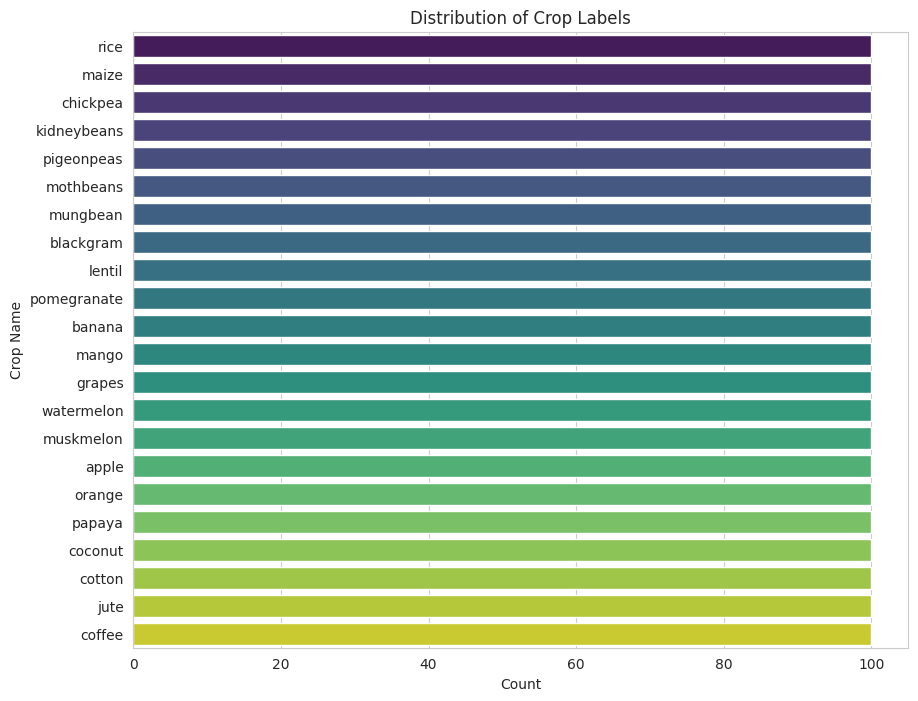

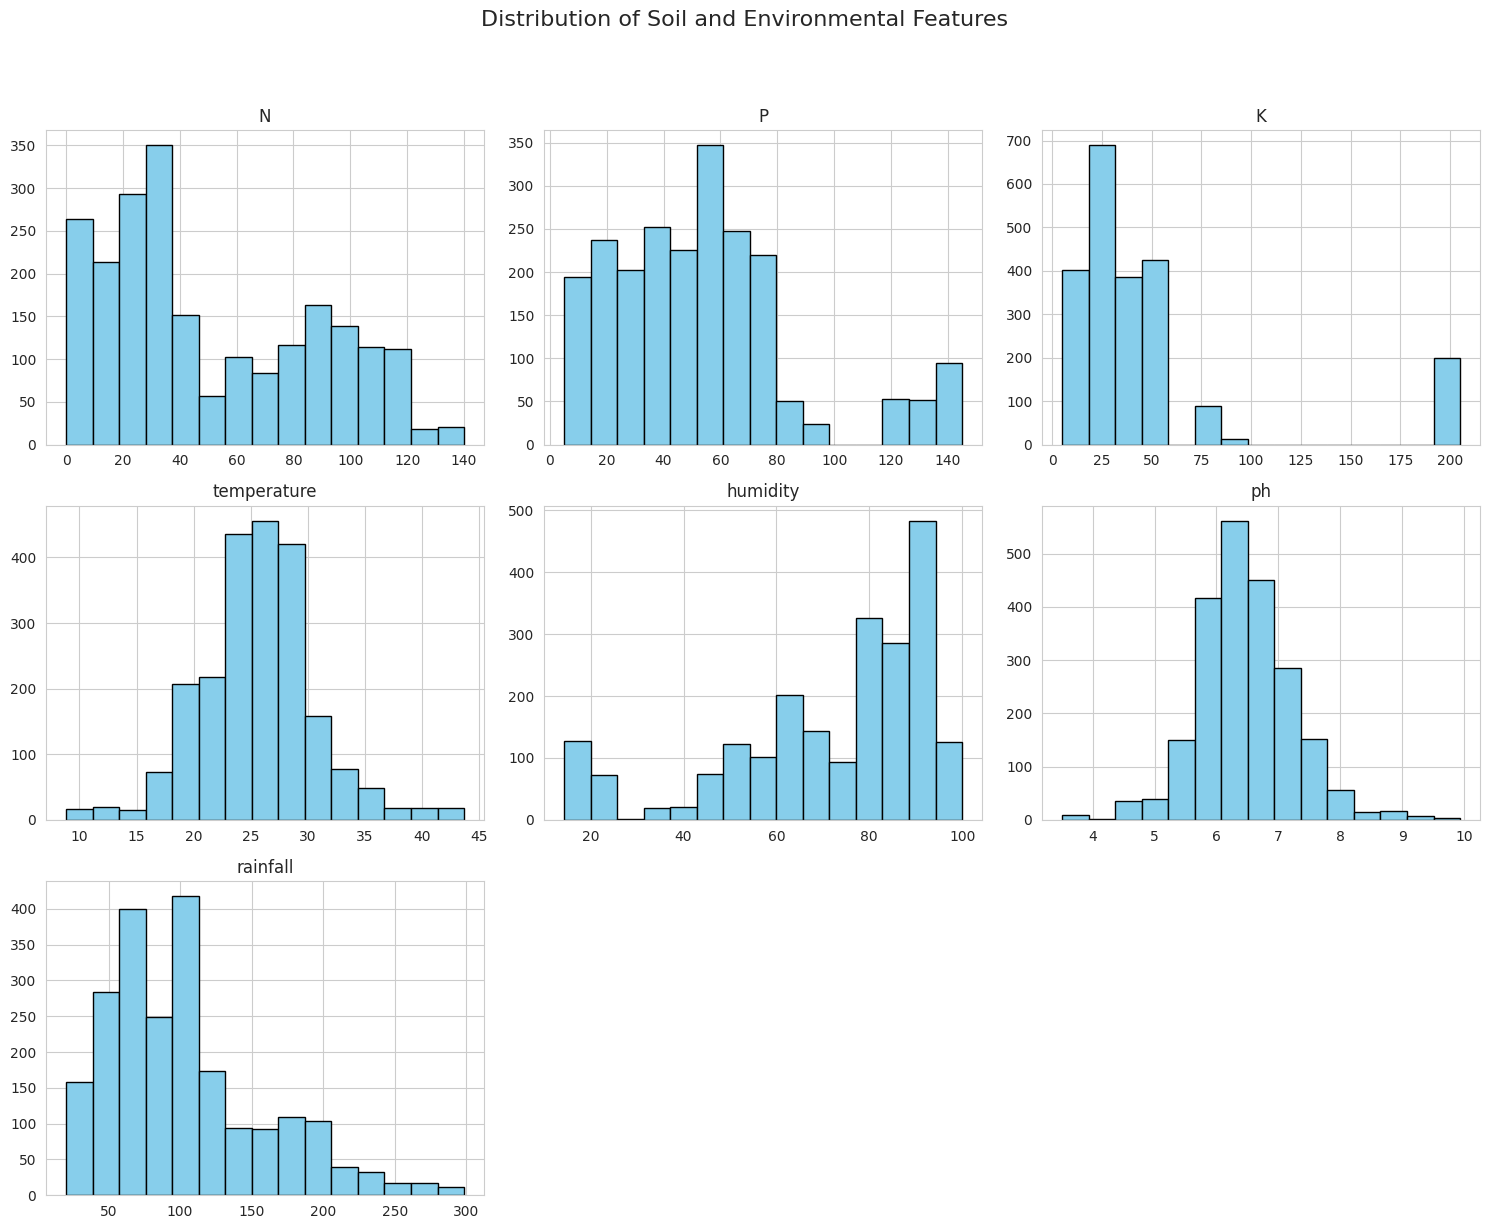

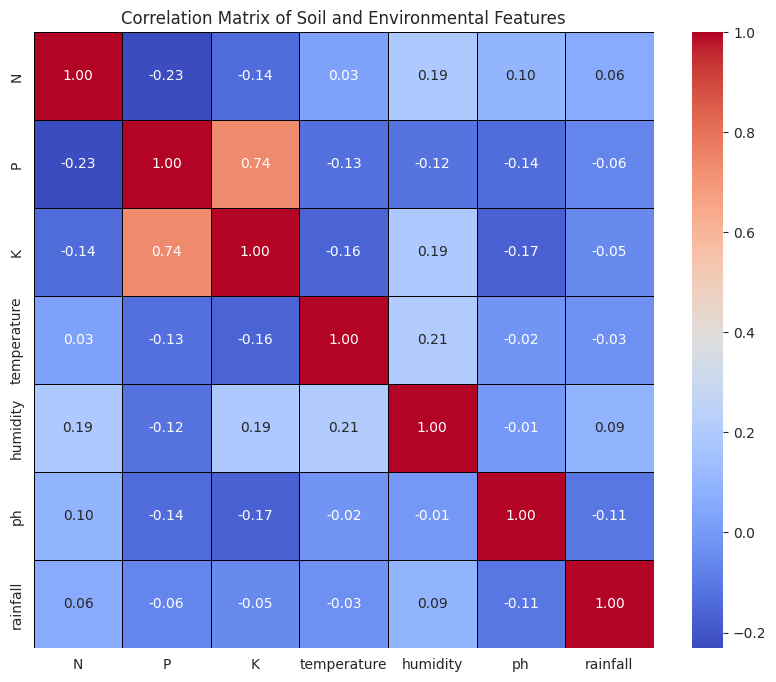

/tmp/ipython-input-987928433.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='label', y='N', data=df, palette='Set2')


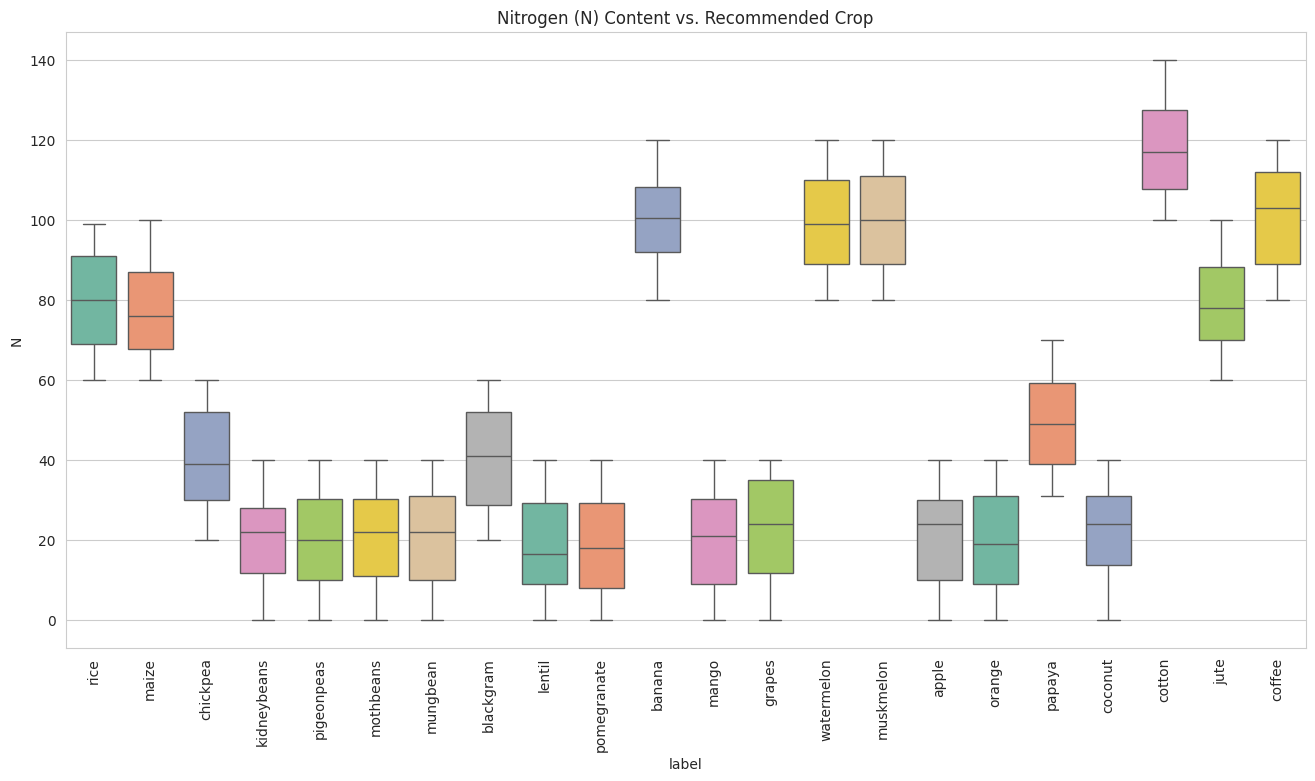

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.figure(figsize=(10, 8))
sns.countplot(y='label', data=df, palette='viridis', order=df['label'].value_counts().index)
plt.title('Distribution of Crop Labels')
plt.xlabel('Count')
plt.ylabel('Crop Name')
plt.show()

numerical_cols = ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']
df[numerical_cols].hist(figsize=(15, 12), bins=15, color='skyblue', edgecolor='black')
plt.suptitle('Distribution of Soil and Environmental Features', y=1.02, fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()

corr_matrix = df[numerical_cols].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5, linecolor='black')
plt.title('Correlation Matrix of Soil and Environmental Features')
plt.show()

plt.figure(figsize=(16, 8))
sns.boxplot(x='label', y='N', data=df, palette='Set2')
plt.xticks(rotation=90)
plt.title('Nitrogen (N) Content vs. Recommended Crop')
plt.show()

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

X = df[['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']]
y = df['label']


scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)


X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

print(f"Data scaled and split successfully.")
print(f"Training set size: {X_train.shape[0]} samples.")

Data scaled and split successfully.
Training set size: 1760 samples.


--- Random Forest Evaluation ---
Accuracy: 99.32%

Classification Report:
              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        23
      banana       1.00      1.00      1.00        21
   blackgram       1.00      1.00      1.00        20
    chickpea       1.00      1.00      1.00        26
     coconut       1.00      1.00      1.00        27
      coffee       1.00      1.00      1.00        17
      cotton       1.00      1.00      1.00        17
      grapes       1.00      1.00      1.00        14
        jute       0.92      1.00      0.96        23
 kidneybeans       1.00      1.00      1.00        20
      lentil       0.92      1.00      0.96        11
       maize       1.00      1.00      1.00        21
       mango       1.00      1.00      1.00        19
   mothbeans       1.00      0.96      0.98        24
    mungbean       1.00      1.00      1.00        19
   muskmelon       1.00      1.00      1.00        17
      o

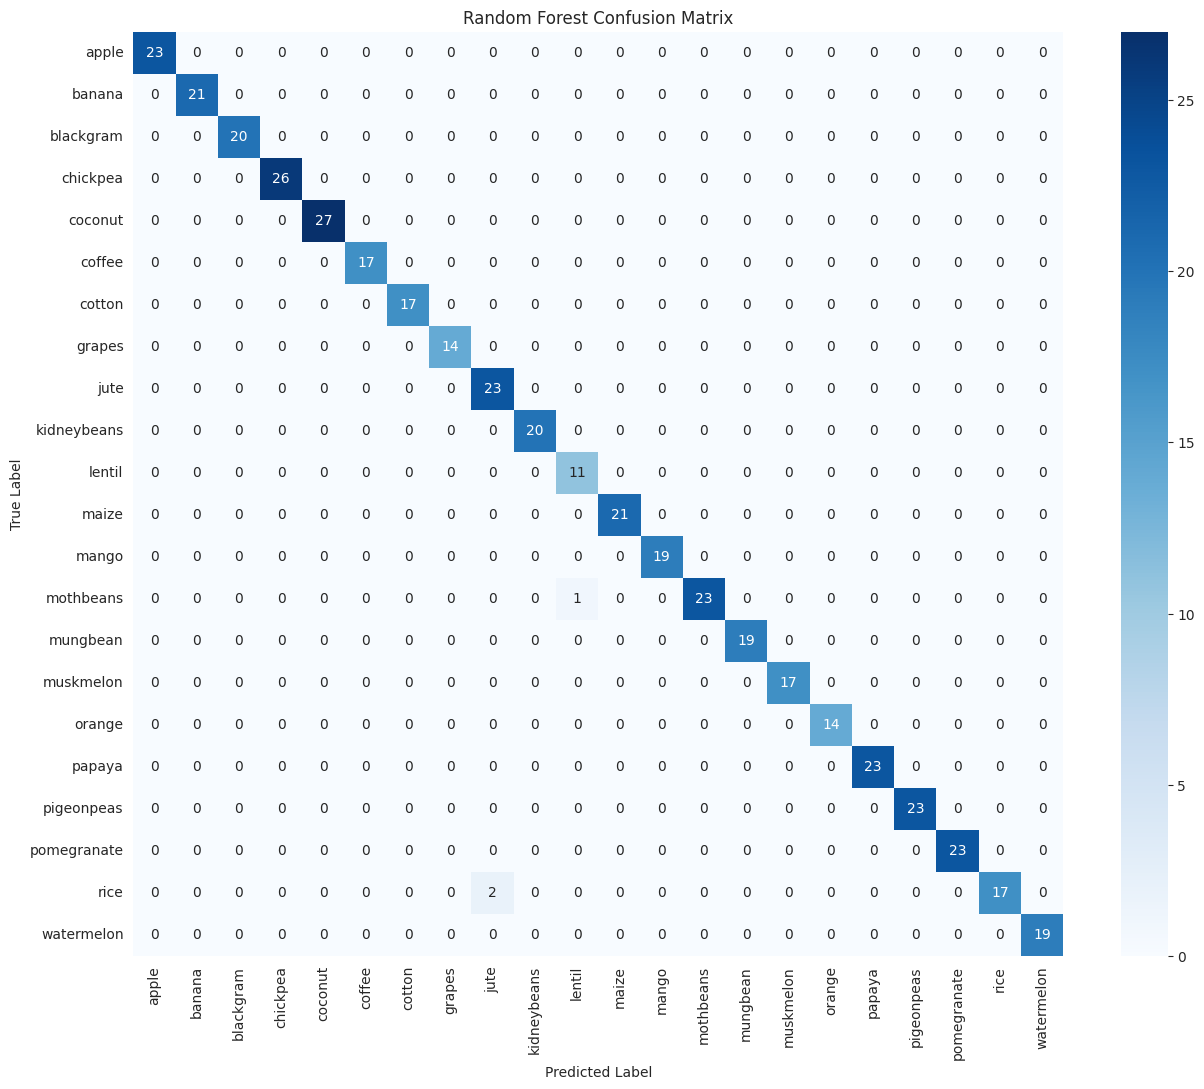

In [6]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

rf_y_pred = rf_model.predict(X_test)

rf_accuracy = accuracy_score(y_test, rf_y_pred)
print("--- Random Forest Evaluation ---")
print(f"Accuracy: {rf_accuracy*100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, rf_y_pred))


cm_rf = confusion_matrix(y_test, rf_y_pred)
plt.figure(figsize=(15, 12))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues',
            xticklabels=rf_model.classes_, yticklabels=rf_model.classes_)
plt.title('Random Forest Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()


--- Support Vector Classifier Evaluation ---
Accuracy: 96.82%

Classification Report:
              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        23
      banana       1.00      1.00      1.00        21
   blackgram       0.95      0.95      0.95        20
    chickpea       1.00      1.00      1.00        26
     coconut       1.00      1.00      1.00        27
      coffee       0.94      1.00      0.97        17
      cotton       0.94      1.00      0.97        17
      grapes       1.00      1.00      1.00        14
        jute       0.81      0.96      0.88        23
 kidneybeans       0.91      1.00      0.95        20
      lentil       0.73      1.00      0.85        11
       maize       1.00      0.95      0.98        21
       mango       1.00      1.00      1.00        19
   mothbeans       1.00      0.88      0.93        24
    mungbean       1.00      1.00      1.00        19
   muskmelon       1.00      1.00      1.00     

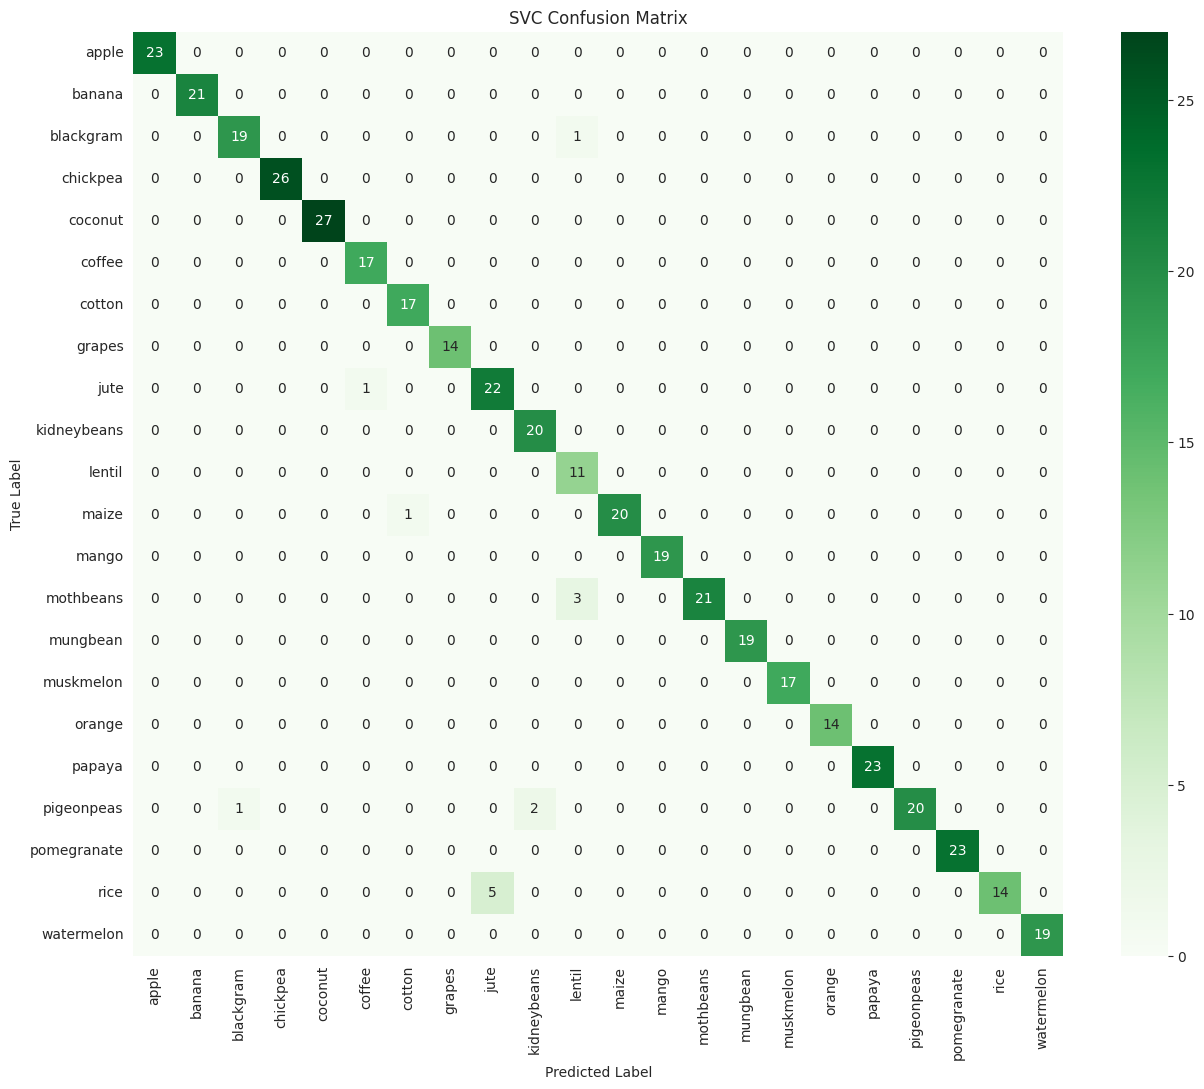

In [7]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

svm_model = SVC(kernel='rbf', random_state=42)
svm_model.fit(X_train, y_train)

svm_y_pred = svm_model.predict(X_test)

svm_accuracy = accuracy_score(y_test, svm_y_pred)
print("\n--- Support Vector Classifier Evaluation ---")
print(f"Accuracy: {svm_accuracy*100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, svm_y_pred))

cm_svm = confusion_matrix(y_test, svm_y_pred)
plt.figure(figsize=(15, 12))
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Greens',
            xticklabels=svm_model.classes_, yticklabels=svm_model.classes_)
plt.title('SVC Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [8]:
import pickle
import os
from google.colab import drive

if not os.path.isdir('/content/drive/MyDrive'):
    drive.mount('/content/drive')

best_model = rf_model # Change to svm_model if it performs better!

save_path = '/content/drive/MyDrive/Crop_Project_Files/'

os.makedirs(save_path, exist_ok=True)

with open(save_path + 'crop_prediction_model.pkl', 'wb') as file:
    pickle.dump(best_model, file)

with open(save_path + 'feature_scaler.pkl', 'wb') as file:
    pickle.dump(scaler, file)

print("\n--- PROJECT ARTIFACTS SAVED ---")
print(f"Model and Scaler saved successfully to: {save_path}")


--- PROJECT ARTIFACTS SAVED ---
Model and Scaler saved successfully to: /content/drive/MyDrive/Crop_Project_Files/


In [9]:
import pickle
import numpy as np
import pandas as pd
import os
from google.colab import drive

try:
    if not os.path.isdir('/content/drive/MyDrive'):
        drive.mount('/content/drive')
except:
    pass

save_path = '/content/drive/MyDrive/Crop_Project_Files/'

with open(save_path + 'crop_prediction_model.pkl', 'rb') as file:
    loaded_model = pickle.load(file)

with open(save_path + 'feature_scaler.pkl', 'rb') as file:
    loaded_scaler = pickle.load(file)

print("Model and Scaler loaded successfully for final testing.")


sample_input = np.array([[60, 70, 89, 20.87, 82.00, 6.50, 202.93]])


sample_scaled = loaded_scaler.transform(sample_input)


prediction = loaded_model.predict(sample_scaled)

print(f"\n--- Recommendation Result ---")
print(f"Input Parameters: {sample_input[0]}")
print(f"The Smart Crop System recommends: **{prediction[0].upper()}**")

Model and Scaler loaded successfully for final testing.

--- Recommendation Result ---
Input Parameters: [ 60.    70.    89.    20.87  82.     6.5  202.93]
The Smart Crop System recommends: **BANANA**


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
